   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
Model Performance Comparison

Linear Regression
Accuracy : 76.94415927057693 %
R2 Score : 0.7694415927057693
MSE : 33805466.898688614
RMSE : 5814.246890069995

Decision Tree
Accuracy : 74.75529409829377 %
R2 Score : 0.7475529409829378
MSE : 37014875.308284365
RMSE : 6083.9851502353595


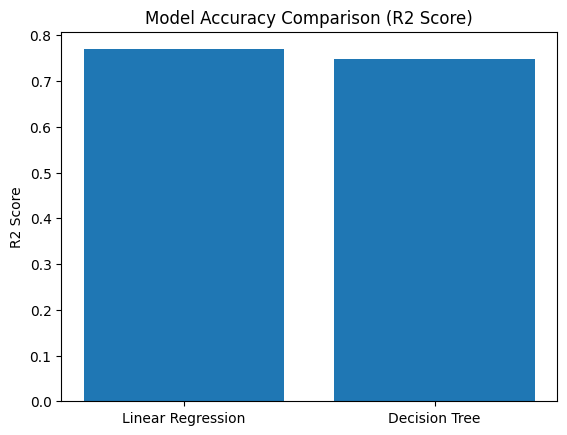

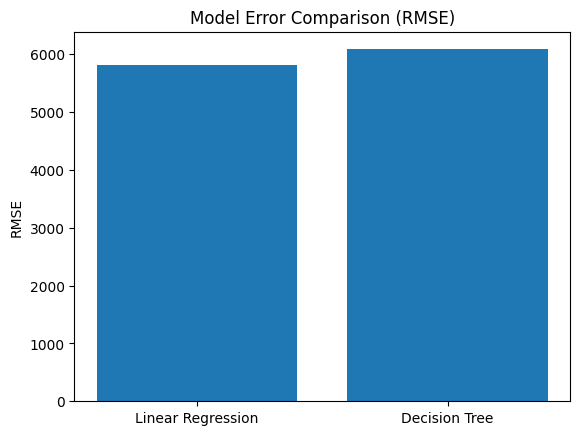

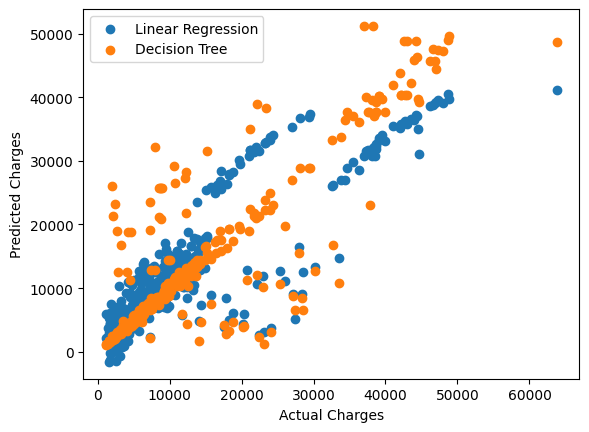

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

data = pd.read_csv("insurance.csv")

print(data.head())

encoder = LabelEncoder()

data["sex"] = encoder.fit_transform(data["sex"])

data["smoker"] = encoder.fit_transform(data["smoker"])

data["region"] = encoder.fit_transform(data["region"])

x = data.drop("charges", axis=1)

y = data["charges"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.3,
    random_state=42
)

lr_model = LinearRegression()

lr_model.fit(x_train, y_train)

lr_pred = lr_model.predict(x_test)

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(x_train, y_train)

dt_pred = dt_model.predict(x_test)

lr_mse = mean_squared_error(y_test, lr_pred)

lr_rmse = np.sqrt(lr_mse)

lr_r2 = r2_score(y_test, lr_pred)

dt_mse = mean_squared_error(y_test, dt_pred)

dt_rmse = np.sqrt(dt_mse)

dt_r2 = r2_score(y_test, dt_pred)

print("Model Performance Comparison")

print("\nLinear Regression")

print("Accuracy :", lr_r2 * 100, "%")

print("R2 Score :", lr_r2)

print("MSE :", lr_mse)

print("RMSE :", lr_rmse)

print("\nDecision Tree")

print("Accuracy :", dt_r2 * 100, "%")

print("R2 Score :", dt_r2)

print("MSE :", dt_mse)

print("RMSE :", dt_rmse)

plt.bar(
    ["Linear Regression", "Decision Tree"],
    [lr_r2, dt_r2]
)

plt.title("Model Accuracy Comparison (R2 Score)")

plt.ylabel("R2 Score")

plt.show()

plt.bar(
    ["Linear Regression", "Decision Tree"],
    [lr_rmse, dt_rmse]
)

plt.title("Model Error Comparison (RMSE)")

plt.ylabel("RMSE")

plt.show()

plt.scatter(y_test, lr_pred, label="Linear Regression")

plt.scatter(y_test, dt_pred, label="Decision Tree")

plt.xlabel("Actual Charges")

plt.ylabel("Predicted Charges")

plt.legend()

plt.show()